In [72]:
#Data Manipulation and Visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Plotting style
sns.set_style("whitegrid")

In [73]:
# Loading the cleaned Titanic dataset
titanic = pd.read_csv("titanic_cleaned.csv")

# Display the first ten rows
titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


In [74]:
print(titanic.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [75]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [76]:
# Removing columns that are not useful for prediction
titanic = titanic.drop(columns=["PassengerId", "Name", "Ticket"])

In [77]:
# Creating a LabelEncoder object
le = LabelEncoder()

# Encoding categorical columns
categorical_columns = ["Sex", "Embarked"]

for col in categorical_columns:
    titanic[col] = le.fit_transform(titanic[col])

# Converting categorical variables into numeric values for model training.

In [78]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [79]:
# Separating the dataset into features (X) and target variable (y).

# Features (independent variables)
X = titanic.drop("Survived", axis=1)

# Target (dependent variable)
y = titanic["Survived"]

In [80]:
# Splitting the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
# Creating an instance of the Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

In [82]:
# Training the Logistic Regression model using the training data.
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [83]:
# Predicting passenger survival for the testing data.
y_pred = log_model.predict(X_test)

In [85]:
# Evaluating the model by calculating the proportion of correct predictions.

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.8100558659217877


In [ ]:
# The Logistic Regression model achieved an accuracy of 81.01%.
# This means the model correctly predicted passenger survival for about 81 out of every 100 passengers in the test dataset.

Confusion Matrix: [[90 15]
 [19 55]]


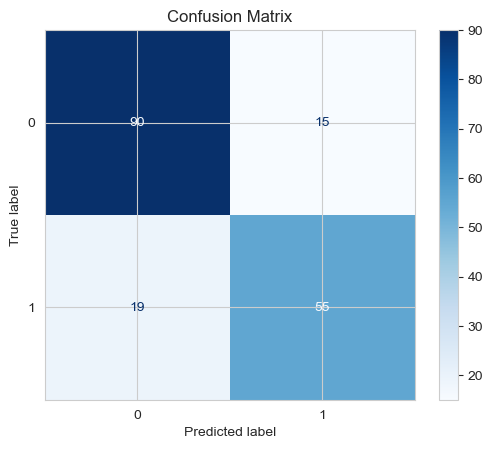

In [89]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:", cm)

# Displaying the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# The confusion matrix shows that the model correctly classified 90 non-survivors and 55 survivors.
# It misclassified 15 non-survivors as survivors and 19 survivors as non-survivors.

In [87]:
# Generate the classification report
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
# Model Type - Logistic Regression Model 
# Model Performance Results

# Evaluation Metric
# Accuracy Score - 81.01%
# Confusion Matrix
#Confusion Matrix: [[90 15]
# [19 55]]

# Interpretation
# - The Logistic Regression model achieved an accuracy of 81.01%, correctly classifying approximately 81 out of every 100 passengers.
# - The confusion matrix shows that the model correctly predicted 90 non-survivors and 55 survivors, while making 34 incorrect predictions.
# - The classification report indicates good overall performance, with balanced precision and recall values. 
#   However, the model was slightly better at identifying passengers who did not survive than those who survived.